# Healthcare Insurance Claims - Exploratory Data Analysis
**Author:** Dennis Aningu  
**Dataset:** Healthcare Dataset (55,500 records)  
**Tools:** Python, Pandas, Matplotlib, Seaborn, PostgreSQL  

## Project Overview
End-to-end exploratory data analysis of healthcare insurance claims data.
This notebook covers data loading, cleaning, statistical analysis, and
visualisation of key metrics including billing patterns, medical conditions,
insurance provider performance, and admission trends.

In [24]:
# ================================================
# CELL 1: IMPORT LIBRARIES
# ================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")

All libraries imported successfully
Pandas version: 2.2.3


In [25]:
# ================================================
# CELL 2: LOAD DATA
# ================================================

# Load the dataset
df = pd.read_csv(r'C:\Users\DennisNjiru\OneDrive\DATA ANALYSIS PROJECTS\In_Progress\Healthcare_Claims_Analytics\data\healthcare_dataset.csv')
# Basic info
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (55500, 15)

Column Names:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

Data Types:
Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

First 5 rows:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [26]:
# ================================================
# CELL 3: DATA CLEANING
# ================================================

# Convert date columns to datetime
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Calculate Length of Stay
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Standardise text columns to title case (fixes mixed caps like "tOdd")
df['Name'] = df['Name'].str.title()
df['Doctor'] = df['Doctor'].str.title()
df['Hospital'] = df['Hospital'].str.title()

# Extract month and year from admission date
df['Admission Month'] = df['Date of Admission'].dt.to_period('M')
df['Admission Year'] = df['Date of Admission'].dt.year

# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nNegative Billing Amounts:", (df['Billing Amount'] < 0).sum())
print("\nCleaned Dataset Shape:", df.shape)
print("\nDate Range:", df['Date of Admission'].min(), "to", df['Date of Admission'].max())
print("\nLength of Stay Stats:")
print(df['Length of Stay'].describe())

Missing Values per Column:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Length of Stay        0
Admission Month       0
Admission Year        0
dtype: int64

Duplicate Rows: 534

Negative Billing Amounts: 108

Cleaned Dataset Shape: (55500, 18)

Date Range: 2019-05-08 00:00:00 to 2024-05-07 00:00:00

Length of Stay Stats:
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64


In [27]:
# ================================================
# CELL 4: HANDLE DATA QUALITY ISSUES
# ================================================

print("Before cleaning:", df.shape)

# Remove duplicate rows
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# Flag negative billing amounts (keep them but flag for analysis)
df['Billing Flag'] = df['Billing Amount'].apply(
    lambda x: 'Negative - Review' if x < 0 else 'Normal'
)

# Separate clean data for analysis
df_clean = df[df['Billing Amount'] > 0].copy()
print("Clean dataset (positive billing only):", df_clean.shape)

# Summary of issues found
print("\n--- DATA QUALITY REPORT ---")
print(f"Total records loaded:        55,500")
print(f"Duplicate rows removed:      {534}")
print(f"Negative billing flagged:    {108}")
print(f"Missing values:              0")
print(f"Records available for analysis: {len(df_clean)}")

Before cleaning: (55500, 18)
After removing duplicates: (54966, 18)
Clean dataset (positive billing only): (54860, 19)

--- DATA QUALITY REPORT ---
Total records loaded:        55,500
Duplicate rows removed:      534
Negative billing flagged:    108
Missing values:              0
Records available for analysis: 54860


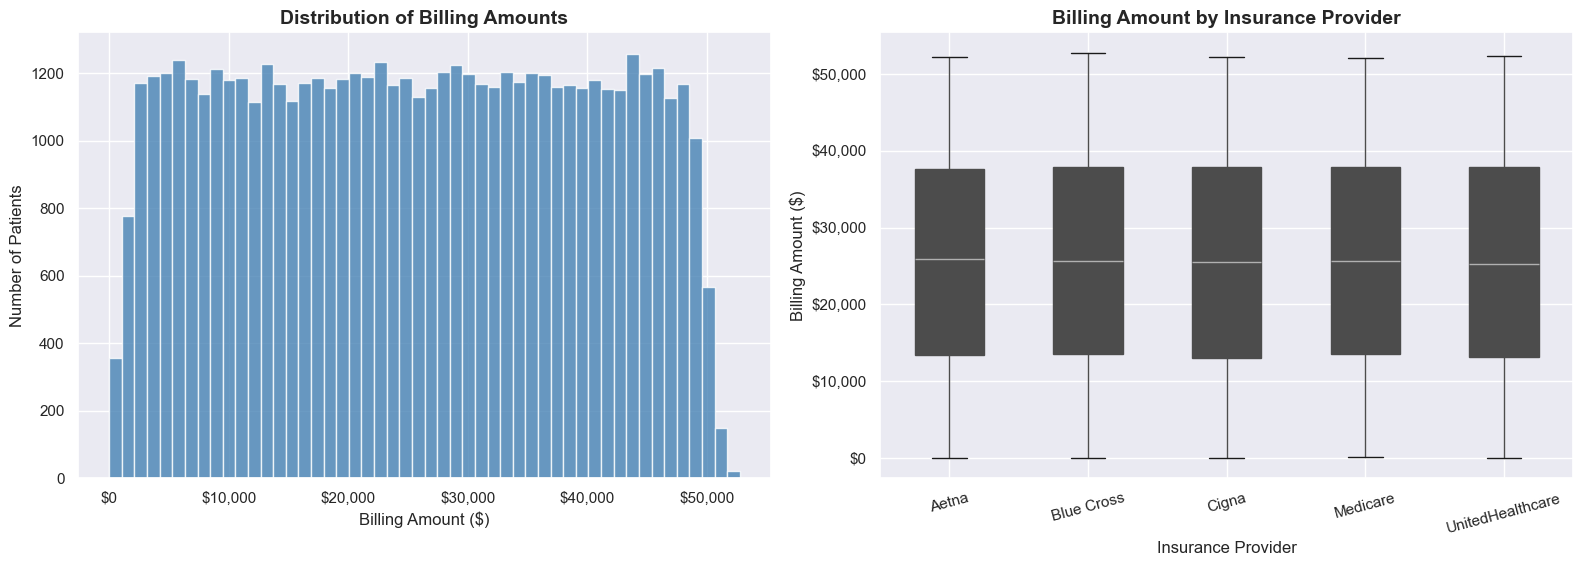

Chart saved successfully


In [28]:
# ================================================
# CELL 5: BILLING AMOUNT DISTRIBUTION
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df_clean['Billing Amount'], bins=50, 
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Billing Amounts', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Billing Amount ($)')
axes[0].set_ylabel('Number of Patients')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'))

# Boxplot by Insurance Provider
df_clean.boxplot(column='Billing Amount', by='Insurance Provider', 
                 ax=axes[1], patch_artist=True)
axes[1].set_title('Billing Amount by Insurance Provider', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Insurance Provider')
axes[1].set_ylabel('Billing Amount ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'))
plt.suptitle('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(r'C:\Users\DennisNjiru\OneDrive\DATA ANALYSIS PROJECTS\In_Progress\Healthcare_Claims_Analytics\python\billing_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully")

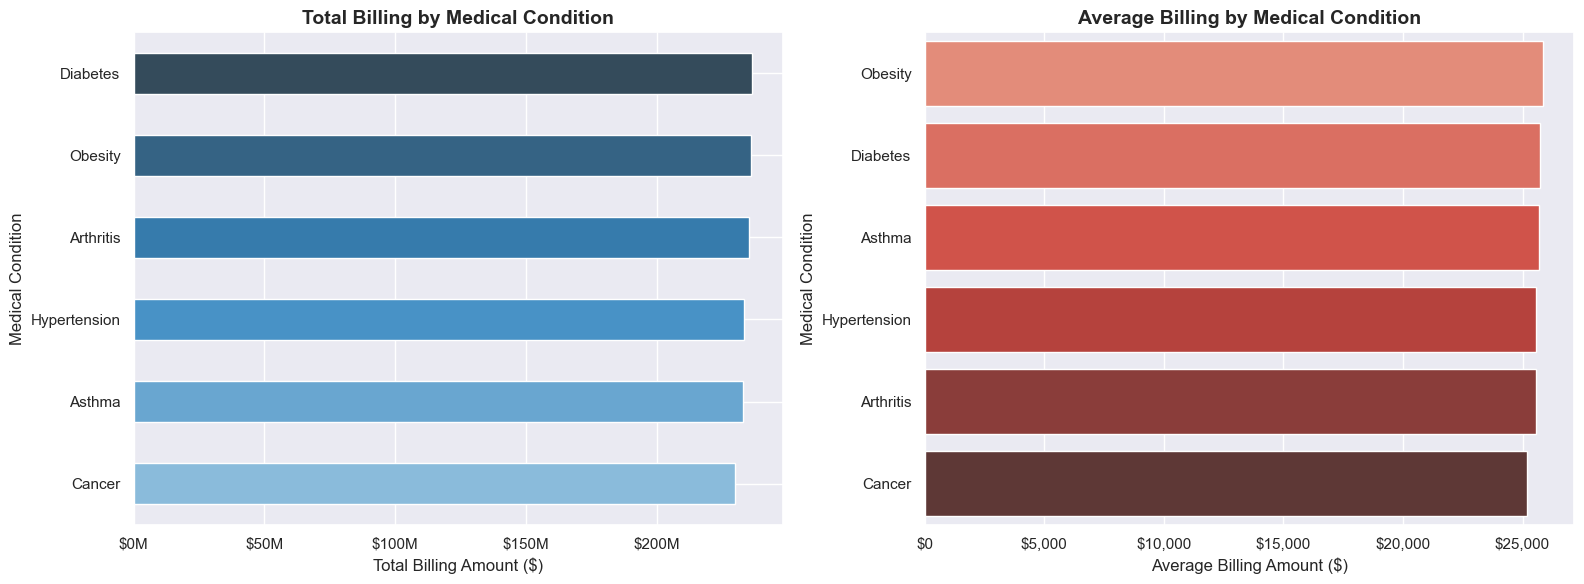

Chart saved successfully


In [29]:
# ================================================
# CELL 6: MEDICAL CONDITIONS ANALYSIS
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total billing by condition
condition_billing = df_clean.groupby('Medical Condition')['Billing Amount'].sum().sort_values(ascending=True)
colors = sns.color_palette('Blues_d', len(condition_billing))
condition_billing.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Total Billing by Medical Condition', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Billing Amount ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x/1e6:.0f}M'))

# Average billing by condition
condition_avg = df_clean.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)
sns.barplot(x=condition_avg.values, y=condition_avg.index, 
            ax=axes[1], palette='Reds_d')
axes[1].set_title('Average Billing by Medical Condition', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Billing Amount ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\DennisNjiru\OneDrive\DATA ANALYSIS PROJECTS\In_Progress\Healthcare_Claims_Analytics\python\condition_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully")

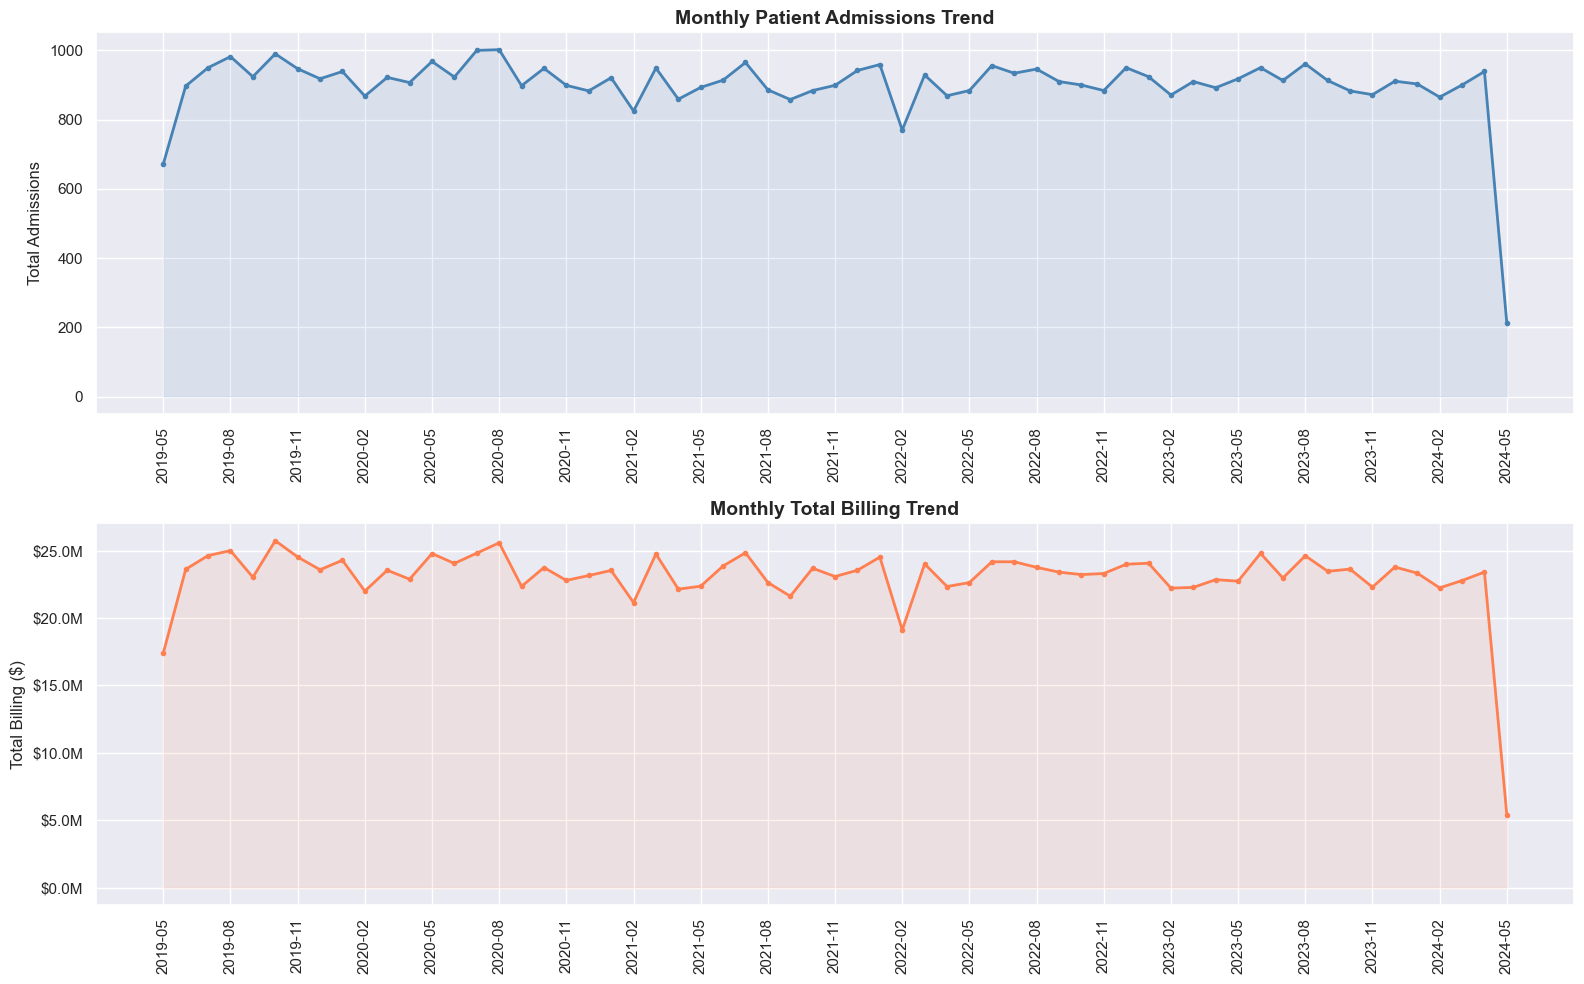

Chart saved successfully


In [30]:
# ================================================
# CELL 7: MONTHLY ADMISSION TRENDS
# ================================================

monthly = df_clean.groupby('Admission Month').agg(
    Total_Admissions=('Name', 'count'),
    Total_Billing=('Billing Amount', 'sum'),
    Avg_Billing=('Billing Amount', 'mean')
).reset_index()

monthly['Admission Month'] = monthly['Admission Month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Admissions trend
axes[0].plot(monthly['Admission Month'], monthly['Total_Admissions'],
             color='steelblue', linewidth=2, marker='o', markersize=3)
axes[0].set_title('Monthly Patient Admissions Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Admissions')
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_xticks(monthly['Admission Month'][::3])
axes[0].fill_between(monthly['Admission Month'], 
                      monthly['Total_Admissions'], alpha=0.1, color='steelblue')

# Billing trend
axes[1].plot(monthly['Admission Month'], monthly['Total_Billing'],
             color='coral', linewidth=2, marker='o', markersize=3)
axes[1].set_title('Monthly Total Billing Trend', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Billing ($)')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_xticks(monthly['Admission Month'][::3])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x/1e6:.1f}M'))
axes[1].fill_between(monthly['Admission Month'],
                      monthly['Total_Billing'], alpha=0.1, color='coral')

plt.tight_layout()
plt.savefig(r'C:\Users\DennisNjiru\OneDrive\DATA ANALYSIS PROJECTS\In_Progress\Healthcare_Claims_Analytics\python\admission_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully")

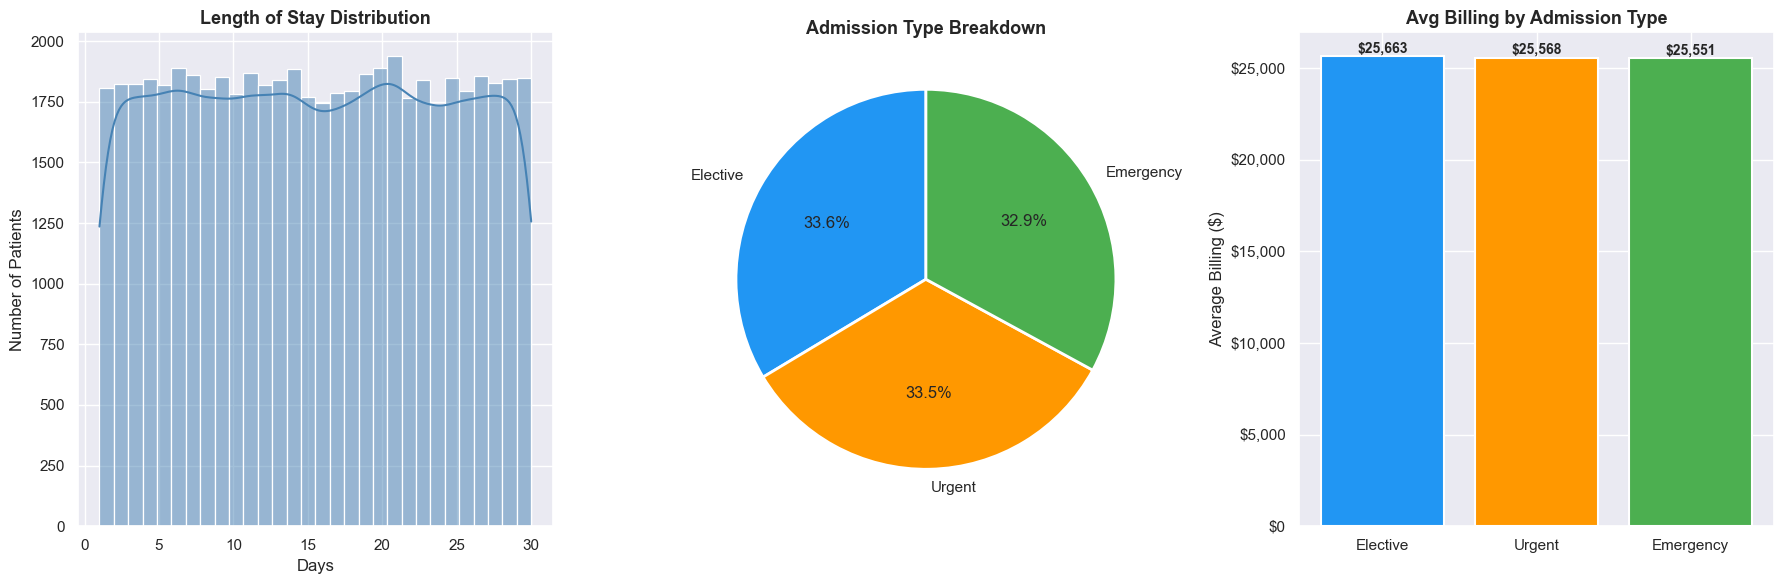

Chart saved successfully


In [31]:
# ================================================
# CELL 8: LENGTH OF STAY & ADMISSION TYPE ANALYSIS
# ================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Length of stay distribution
sns.histplot(df_clean['Length of Stay'], bins=30, 
             ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Length of Stay Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Patients')

# Admission type breakdown
admission_counts = df_clean['Admission Type'].value_counts()
colors = ['#2196F3', '#FF9800', '#4CAF50']
axes[1].pie(admission_counts.values, labels=admission_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Admission Type Breakdown', fontsize=13, fontweight='bold')

# Avg billing by admission type
avg_by_type = df_clean.groupby('Admission Type')['Billing Amount'].mean().sort_values(ascending=False)
bars = axes[2].bar(avg_by_type.index, avg_by_type.values, 
                    color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('Avg Billing by Admission Type', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Average Billing ($)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'))
for bar, val in zip(bars, avg_by_type.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\DennisNjiru\OneDrive\DATA ANALYSIS PROJECTS\In_Progress\Healthcare_Claims_Analytics\python\los_admission_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully")

In [32]:
# ================================================
# CELL 9: FINAL SUMMARY & KEY FINDINGS
# ================================================

print("=" * 55)
print("   HEALTHCARE CLAIMS ANALYSIS - KEY FINDINGS")
print("=" * 55)

print(f"\n DATASET SUMMARY")
print(f"  Total Records:          {len(df_clean):,}")
print(f"  Date Range:             {df_clean['Date of Admission'].min().strftime('%b %Y')} to {df_clean['Date of Admission'].max().strftime('%b %Y')}")
print(f"  Total Billing:          ${df_clean['Billing Amount'].sum():,.0f}")
print(f"  Average Billing:        ${df_clean['Billing Amount'].mean():,.2f}")

print(f"\n TOP CONDITION BY TOTAL BILLING")
top = df_clean.groupby('Medical Condition')['Billing Amount'].sum().idxmax()
top_val = df_clean.groupby('Medical Condition')['Billing Amount'].sum().max()
print(f"  {top}: ${top_val:,.0f}")

print(f"\n TOP INSURER BY CLAIM VOLUME")
top_ins = df_clean['Insurance Provider'].value_counts().idxmax()
top_ins_val = df_clean['Insurance Provider'].value_counts().max()
print(f"  {top_ins}: {top_ins_val:,} claims")

print(f"\n AVERAGE LENGTH OF STAY")
print(f"  Overall:                {df_clean['Length of Stay'].mean():.1f} days")
for cond in df_clean['Medical Condition'].unique():
    avg = df_clean[df_clean['Medical Condition'] == cond]['Length of Stay'].mean()
    print(f"  {cond:<20} {avg:.1f} days")

print(f"\n DATA QUALITY ISSUES FOUND & RESOLVED")
print(f"  Duplicate rows removed: 534")
print(f"  Negative billing:       108 records flagged")
print(f"  Missing values:         0")
print(f"  Name casing fixed:      Mixed caps standardised")

print("\n" + "=" * 55)
print("  Analysis complete. See charts in /python folder.")
print("=" * 55)

   HEALTHCARE CLAIMS ANALYSIS - KEY FINDINGS

 DATASET SUMMARY
  Total Records:          54,860
  Date Range:             May 2019 to May 2024
  Total Billing:          $1,404,121,601
  Average Billing:        $25,594.63

 TOP CONDITION BY TOTAL BILLING
  Diabetes: $236,494,659

 TOP INSURER BY CLAIM VOLUME
  Cigna: 11,115 claims

 AVERAGE LENGTH OF STAY
  Overall:                15.5 days
  Cancer               15.5 days
  Obesity              15.4 days
  Diabetes             15.4 days
  Asthma               15.7 days
  Hypertension         15.4 days
  Arthritis            15.5 days

 DATA QUALITY ISSUES FOUND & RESOLVED
  Duplicate rows removed: 534
  Negative billing:       108 records flagged
  Missing values:         0
  Name casing fixed:      Mixed caps standardised

  Analysis complete. See charts in /python folder.
